## Initialization

In [2]:
%load_ext autoreload
%autoreload 2
%autosave 0
%precision %g

import sys, os, glob, time
import re
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.lines as lines
import functools as ft
import numpy as np
import numpy.random as rnd
import scipy.integrate as integ
import qiskit as qk
import qiskit_aer as aer
import qiskit_algorithms as qalgo
import qiskit_ibm_runtime as qkrun
import qiskit_experiments as qkexp
import qiskit_braket_provider as braket

# Launch Wolfram language interface
# from wolframclient.evaluation import WolframLanguageSession
# from wolframclient.language import wl, wlexpr
# wl_session = WolframLanguageSession()

from tqdm import tqdm

import sys

sys.path.append("../")

# Directories
# if os.uname().sysname == 'Linux':
#     base_dir = os.path.expanduser("~/sn-quant/")
# else:
#     base_dir = os.path.expanduser("~/Dropbox/sn-quant/jk/")

base_dir = os.path.join("../", "joachim")
os.chdir(base_dir)

# set up matplotlib
%matplotlib inline
# matplotlib.rcParams['text.usetex']    = True
# matplotlib.rcParams['text.latex.preamble'] = r'\usepackage{amsmath,amssymb}'
matplotlib.rcParams['font.family']    = 'serif'
matplotlib.rcParams['font.size']      = '16'
# matplotlib.rcParams['figure.figsize'] = 6.4, 4.8
matplotlib.rcParams['figure.figsize'] = 16, 8

# Unit conversion and physical constants
class my_units:
    # Energy and mass
    eV     = 1.
    keV    = 1.e3
    MeV    = 1.e6
    GeV    = 1.e9
    TeV    = 1.e12
    PeV    = 1.e15
    kg     = 5.62e35*eV
    grams  = 0.001*kg
    Kelvin = 8.617333262e-5       # PDG 2022
    Joule  = 1/1.602176634e-19*eV # PDG 2022 [exact]
    erg    = 1e-7*Joule
    
    # Length and time
    m     = 5.076e6
    meter = m
    km    = 1000*m
    cm    = 0.01*m
    nm    = 1.e-9*m
    fm    = 1.e-15*m
    AU    = 1.4960e11*m
    pc    = 30.857e15*m
    kpc   = 1.e3*pc
    Mpc   = 1.e6*pc
    Gpc   = 1.e9*pc
    ly    = 9460730472580800*m  # light year
    sec   = 1.523e15
    hours = 3600*sec
    days  = 24*hours
    yrs   = 365*days
    Hz    = 1./sec
    kHz   = 1.e3*Hz
    MHz   = 1.e6*Hz
    GHz   = 1.e9*Hz
    
    barn  = 1.e-24*cm**2
    pb    = 1.e-36*cm**2
    fb    = 1.e-39*cm**2
    
    # Various astrophysical constants
    GN    = 6.708e-39/1e18  # eV^-2, Newton's constant
    MPl   = 1.22093e19*GeV   # Planck mass, PDG 2013
    Msun  = 1.989e30*kg
    Rsun  = 6.9551e8*meter
    
    # cosmology
    h        = 0.674                         # according to Planck 2018
    H0       = h * 100. * km / sec/ Mpc      # Hubble parameter
    rho_c0   = 3. * H0**2/(8. * np.pi * GN)  # critical density today, Kolb Turner eq. (3.14)
    Omega_dm = 0.12 / h**2                   # dark matter density, Planck 2018
    
    # particle physics
    alpha_em = (1./137.035999139)            # electromagnetic fine structure constant (PDG 2018)
    GF       = 1.166378e-5 / GeV**2          # Fermi constant (PDG 2022)
    s2thW    = 1.03232 * 0.23121             # sin^2 \theta_W(M_Z) from PDG 2022; \kappa from https://arxiv.org/abs/1608.02671
    m_e      = 0.5109989461 * MeV            # electron mass (PDG 2018)
    m_mu     = 105.6583745 * MeV             # muon mass (PDG 2018)
    m_tau    = 1776.86 * MeV                 # tau mass (PDG 2018)
    m_p      = 938.2720813 * MeV             # proton mass (PDG 2018)
    m_n      = 939.565413 * MeV              # neutron mass (PDG 2018)
    m_u      = 931.4940954 * MeV             # atomic mass unit (PDG 2018)
    m_pi0    = 134.9768 * MeV                # neutral pion mass (PDG 2020)
    tau_mu   = 2.1969811e-6 * sec            # muon lifetime (PDG 2018)
    gA       = 1.26                          # axial coupling constant of the proton
    
    # PDG codes
    pdg_nu_e      = 12
    pdg_nu_mu     = 14
    pdg_nu_tau    = 16
    pdg_e         = 11
    pdg_mu        = 13
    pdg_tau       = 15
    pdg_gamma     = 22
    pdg_pip       = 211
    pdg_pi0       = 111
    pdg_KL        = 130
    pdg_Kp        = 321
    pdg_Dp        = 411
    pdg_D0        = 421
    pdg_Dp2s_2460 = 415
    pdg_D02s_2460 = 425
    pdg_Dsp       = 431
    pdg_Dsps      = 433
    pdg_Ds2s_2573 = 435
    
u = my_units()

# Pauli matrices
sigma_0 = np.array([[1, 0],  [0,  1]])
sigma_1 = np.array([[0, 1],  [1,  0]])
sigma_2 = np.array([[0,-1j], [1j, 0]])
sigma_3 = np.array([[1, 0],  [0, -1]])


Autosave disabled


## Raffelt–Sigl Polarization-Vector Approach to Collective Oscillations

In [3]:
def P_osc_RS(t_table, theta, Delta, lam, J, initial_flavors=None, alpha=None):
    """Compute an oscillation probability for collective oscillations
       in the Raffelt-Sigl 2-flavor polarization vector approach.
       
       Arguments:
           t_table: list of time steps
           theta:   vacuum mixing angle
           Delta:   vector of vacuum oscillation frequencies for each mode
           lam:     strength of ordinary matter effect
           J:       matrix of coupling strengths between modes
           initial_flavors: an array of length n_modes indicating the initial flavor of
                    each neutrino ('e', 'x', or 'a'). If any neutrino has flavor 'a',
                    an angle alpha must be specified.
           alpha:   initial superposition for neutrinos in flavor 'a'
    """
    
    n_modes = J.shape[0]
    
    # definition of the vectors B, D, L, P, H, e3m in the notation of
    # https://arxiv.org/abs/1001.2799 (Duan, Fuller Qian)
    u   = np.array([[np.cos(theta), np.sin(theta)], [-np.sin(theta), np.cos(theta)]])
    b   = 0.5 * np.diag([-1,1])
    b   = u @ b @ u.T
    l   = np.diag([1,0])
    
    Ee  = np.array([0, 0,  1.])
    Emu = np.array([0, 0, -1.])
    B   = np.real(np.array([np.trace(b@sigma_1), np.trace(b@sigma_2), np.trace(b@sigma_3)]))
    L   = np.real(np.array([np.trace(l@sigma_1), np.trace(l@sigma_2), np.trace(l@sigma_3)]))
    
    ini_state = np.where(Delta>0, Ee[:,None], Emu[:,None])
    if initial_flavors is not None:
        for f in initial_flavors:
            if f not in ['e','x','mu','a']:
                raise ValueError(f'Unknown flavor: {f}')
            if f == 'a' and alpha is None:
                raise ValueError('Initial superposition for neutrinos in flavor "a" not specified')
        ini_state[:,initial_flavors=='e']  = Ee[:,None]
        ini_state[:,initial_flavors=='x']  = Emu[:,None]
        ini_state[:,initial_flavors=='mu'] = Emu[:,None]
        ini_state[:,initial_flavors=='a']  = np.array([np.sin(2*alpha), 0, np.cos(2*alpha)])[:,None]
        # FIXME I'm not sure this is correct
        
    def f(t, P):
        """right-hand side of the evolution equation for the polarization vector P at time t."""
        
        res = np.zeros(3*n_modes)
        PP  = np.reshape(P, (n_modes,3)).T
        for k in range(n_modes):
            res[3*k:3*k+3] = np.cross(Delta[k]*B + lam*L + PP@J[k,:], PP[:,k])
        return res

    return integ.solve_ivp(f, (t_table[0],t_table[-1]), ini_state.T.flatten(), t_eval=t_table)

def P_osc_RS_bipolar(t_table, theta, Delta, lam, J, eps=0.1):
    """Compute an oscillation probability for collective oscillations
       in the Raffelt-Sigl 2-flavor polarization vector approach for
       a bipolar system.
       
       Arguments:
           t_table: list of time steps
           theta:   vacuum mixing angle
           Delta:   vector of vacuum oscillation frequencies for each mode
           lam:     strength of ordinary matter effect
           J:       matrix of coupling strengths between modes
           eps:     asymmetry between neutrinos and anti-neutrinos"""
    
    n_modes = J.shape[0]
    
    # definition of the vectors B, D, L, P, H, e3m in the notation of
    # https://arxiv.org/abs/1001.2799 (Duan, Fuller, Qian)
    u   = np.array([[np.cos(theta), np.sin(theta)], [-np.sin(theta), np.cos(theta)]])
    b   = 0.5 * np.diag([-1,1])
    b   = u @ b @ u.T
    l   = np.diag([1,0])
    
    Ee  = np.array([0, 0,  1+eps])
    Emu = np.array([0, 0, -1+eps])
    B   = np.array([np.trace(b@sigma_1), np.trace(b@sigma_2), np.trace(b@sigma_3)])
    L   = np.array([np.trace(l@sigma_1), np.trace(l@sigma_2), np.trace(l@sigma_3)])
    
    def f(t, P):
        """right-hand side of the evolution equation for the polarization vector P at time t."""
        
        res = (0+0j)*np.zeros(3*n_modes)
        PP  = np.reshape(P, (n_modes,3)).T
        for k in range(n_modes):
            s  = 1 if k < n_modes//2 else -1
            res[3*k:3*k+3] = np.cross(s*Delta[k]*B + lam*L + PP@J[k,:], PP[:,k])
        return res
            
    E0 = np.concatenate((np.tile(Ee,n_modes//2), np.tile(Emu,n_modes//2)))
    return integ.solve_ivp(f, (t_table[0],t_table[-1]), E0, t_eval=t_table)    


/Users/erma/Documents/QNova/venv/lib/python3.12/site-packages/scipy/integrate/_ivp/base.py:23: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(fun(t, y), dtype=dtype)


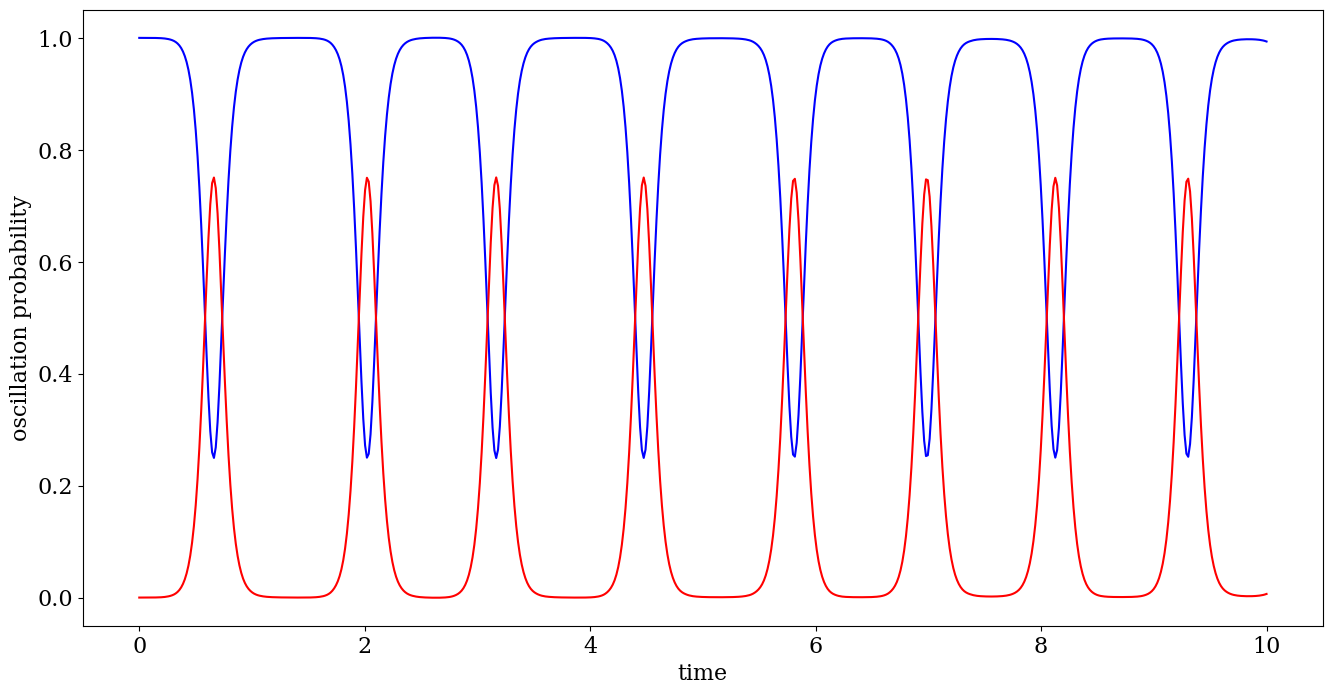

In [4]:
# test for bipolar oscillations
n_modes    = 2
n_nu       = 1
n_nubar    = 1
nu_mask    = np.array([True] *n_nu + [False]*n_nubar)
nubar_mask = np.array([False]*n_nu + [True] *n_nubar)
dmsq       = -1.0
E          = 0.1
J          = 10*np.ones((n_modes,n_modes))
#J[np.ix_(nu_mask,nubar_mask)] *= -1
#J[np.ix_(nubar_mask,nu_mask)] *= -1
t_table    = np.linspace(0,10,20*31)
sol        = P_osc_RS_bipolar(t_table, theta=0.01, Delta=dmsq/(2*E)*np.ones(n_modes), lam=0, J=J, eps=0)
P_table    = np.reshape(sol.y, (n_modes,3,len(t_table)))
for k in range(n_modes):
    plt.plot(t_table, 0.5*(1+P_table[k,2,:]), color='blue' if nu_mask[k] else 'red')
plt.xlabel('time')
plt.ylabel('oscillation probability')
plt.show()

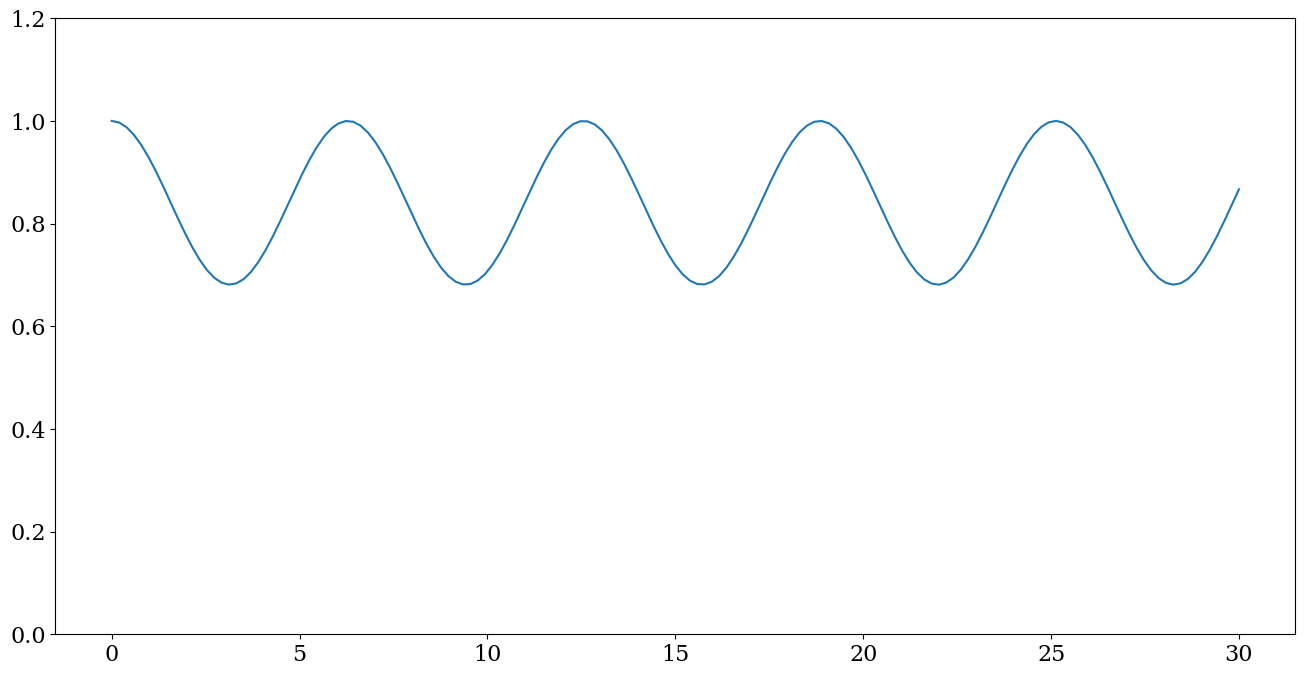

In [5]:
# test for vacuum oscillations
n_modes = 1
J       = np.zeros((n_modes,n_modes))
t_table = np.linspace(0,30,5*31)
sol = P_osc_RS(t_table, 0.3, 1.*np.ones(n_modes), 0, J)

t_table = sol.t
P_table = np.reshape(sol.y, (n_modes,3,len(t_table)))
for k in range(n_modes):
    plt.plot(t_table, 0.5*(1+P_table[k,2,:]))
plt.ylim(0,1.2)
plt.show()

## Bipolar Oscillations

Here, we simulate an interacting 4-neutrino system (2 neutrinos, 2 anti-neutrinos) in an attempt to reproduce bipolar oscillations, as described in Duan & Fuller (https://arxiv.org/abs/1001.2799).

[[10. 10. -5. -5.]
 [10. 10. -5. -5.]
 [-5. -5. 10. 10.]
 [-5. -5. 10. 10.]]


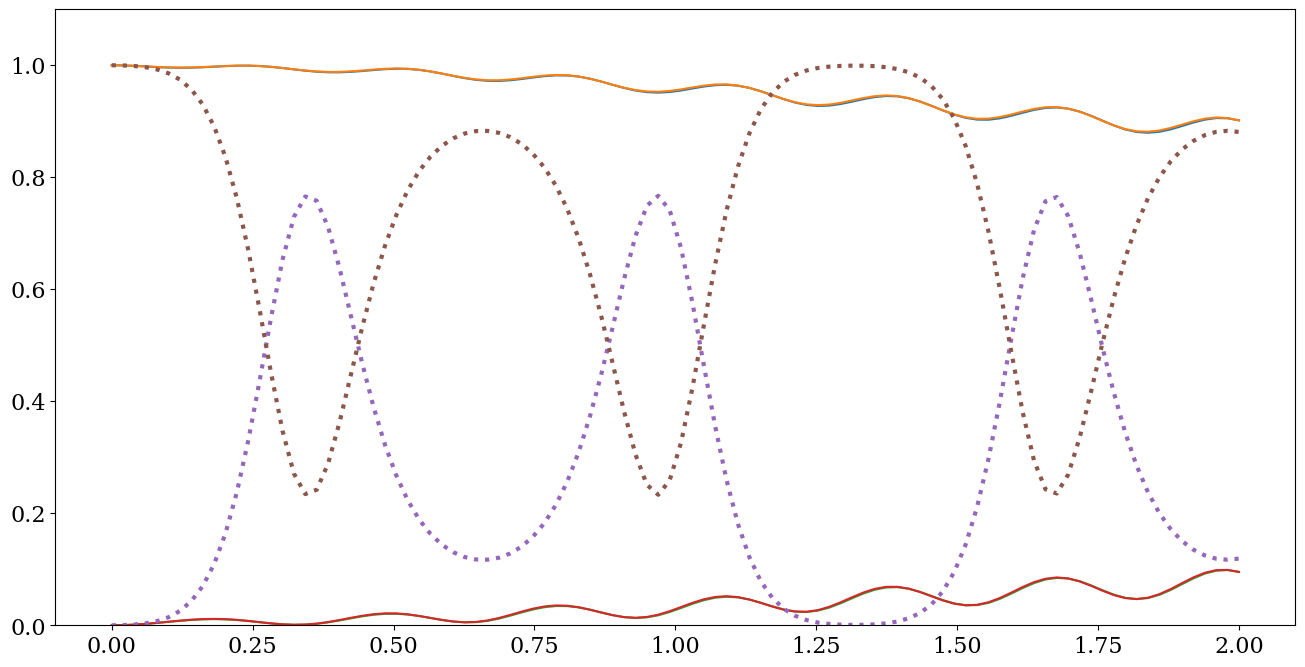

In [12]:
"""
Original version
"""

L          = 2                          # baseline
t_steps    = 100                        # number of Trotter steps
theta      = 10 * np.pi/180.            # vacuum mixing angle
dmsq       = 1.0                        # mass squared difference
Delta      = dmsq / (2*0.1) * np.array([1.,1.,-1.,-1.])       # oscillation frequency; note the minus sign for the kinetic terms for antineutrinos
b          = np.array([np.sin(2*theta), 0, -np.cos(2*theta)]) # the structure of the vacuum Hamiltonian in the Pauli basis
J          = 5 * np.ones((4, 4))        # self-interaction strength
nu_mask    = [True,True,False,False]    # which qubits describe neutrinos?
nubar_mask = [False,False,True,True]    # which qubits describe antineutrinos?
J[nubar_mask,:] *= -1   # minus sign for mixed neutrino--antineutrino terms
J[:,nubar_mask] *= -1

# compute mean-field solution
L_table = np.linspace(0, L, t_steps)
sol     = P_osc_RS(L_table, theta, np.array([Delta[0], -Delta[0]]), 0., 2*J[::2,::2]) # factor 2 because we compare to a system with 2 nu + 2 nubar
P_table = np.reshape(sol.y, (2,3,len(L_table)))

# as neutrinos don't interact with themselves in the quantum algorithm,
# their same-sign partner is given double weight. This way, each particle
# should see the same effective number of neutrinos and antineutrinos.
J[np.ix_(nu_mask,nu_mask)]       *= 2
J[np.ix_(nubar_mask,nubar_mask)] *= 2
print(J)

# determine step size based on derivative of classical solution so that shorter Trotter steps are
# used in regions of rapid oscillation
# L_table_quant  = np.concatenate(([0], np.cumsum(1/np.abs(np.diff(P_table[0,2])))))
# L_table_quant *= L_table[-1]/L_table_quant[-1]
L_table_quant = L_table # FIXME FIXME

# loop over time steps
n_qubits = 4
dt_table = np.diff(L_table_quant)
qc = qk.QuantumCircuit(n_qubits)
for i in range(len(dt_table)):
    dt = dt_table[i]

    # artificially remove entanglement between qubits (but not the superposition that each
    # qubit is in) by resetting each qubit to a non-entangled state
    qc_no_save = qc.remove_final_measurements(inplace=False)
    qc_no_save.data = [inst for inst in qc.data if inst.operation.name != 'save_density_matrix']
    sv = qk.quantum_info.Statevector(qc_no_save)
    rho = [ np.array(qk.quantum_info.partial_trace(sv, [j for j in range(n_qubits) if j != k])) for k in range(n_qubits) ]
    p   = [ np.real(np.array([ np.trace(sigma_1@rho[k]), np.trace(sigma_2@rho[k]), np.trace(sigma_3@rho[k]) ])) for k in range(n_qubits) ]

    # reset antineutrino states to the result from the mean-field formalism
    # p[2] = np.array([-P_table[1,0,i], -P_table[1,1,i], -P_table[1,2,i]])
    # # p[2] = np.array([p[0][0], -p[0][1], p[0][2]])
    # p[1] = p[0]
    # p[3] = p[2]

    # reset neutrino states to the result from the mean-field formalism
    # p[0] = np.array([P_table[0,0,i], P_table[0,1,i], P_table[0,2,i]])
    # p[1] = p[0]
    # p[3] = p[2]
    
    qc.reset(range(n_qubits))
    for j in range(n_qubits):
        qc.ry(np.arccos(p[j][2]), j)
        qc.rz(np.arctan2(p[j][1], p[j][0]), j)

    # save density matrix after each Trotter step for the final plot    
    qc.save_density_matrix(label=str(i+1))

    # carry out Trotter step (2nd-order Trotterization)
    for j in range(4):
        for k in range(j+1,4):
            qc.rx(dt*Delta[j]*b[0]/3, j)  # vacuum # FIXME sign???
            qc.rz(dt*Delta[j]*b[2]/3, j)
            qc.rx(dt*Delta[k]*b[0]/3, k)
            qc.rz(dt*Delta[k]*b[2]/3, k)
            qc.rxx(-dt*J[j,k], j, k)      # self-interaction
            qc.ryy(-dt*J[j,k], j, k)
            qc.rzz(-dt*J[j,k], j, k)
# end for (time steps)

# save final state
qc.save_density_matrix(label=str(i+2))

# run simulation    
sim = aer.AerSimulator(method="statevector", precision="double", zero_threshold=1e-14, validation_threshold=1e-12)
result = sim.run(qc).result()

# extract and plot results
n_qubits = qc.num_qubits
rho_reduced = [ { k : np.array(qk.quantum_info.partial_trace(result.data()[k], [q for q in range(n_qubits) if q != j])) for k in result.data().keys() } for j in range(n_qubits) ]
pp = np.array([ [[float(k), rho_reduced[j][k][0,0]] for k in rho_reduced[j].keys() ] for j in range(n_qubits) ])
pp = np.abs(np.take_along_axis(pp, pp[:,:,0].argsort(axis=1)[:,:,None], axis=1))
for j in range(n_qubits):
    plt.plot(L_table_quant, pp[j,:,1] if nu_mask[j] else 1-pp[j,:,1])
for k in range(len(P_table)):
    plt.plot(L_table, 0.5*(1-P_table[k,2,:]), ls=':', lw=3)
plt.ylim(0,1.1)
plt.show()

[[10. 10. -5. -5.]
 [10. 10. -5. -5.]
 [-5. -5. 10. 10.]
 [-5. -5. 10. 10.]]


100%|██████████| 127/127 [00:11<00:00, 11.43it/s]


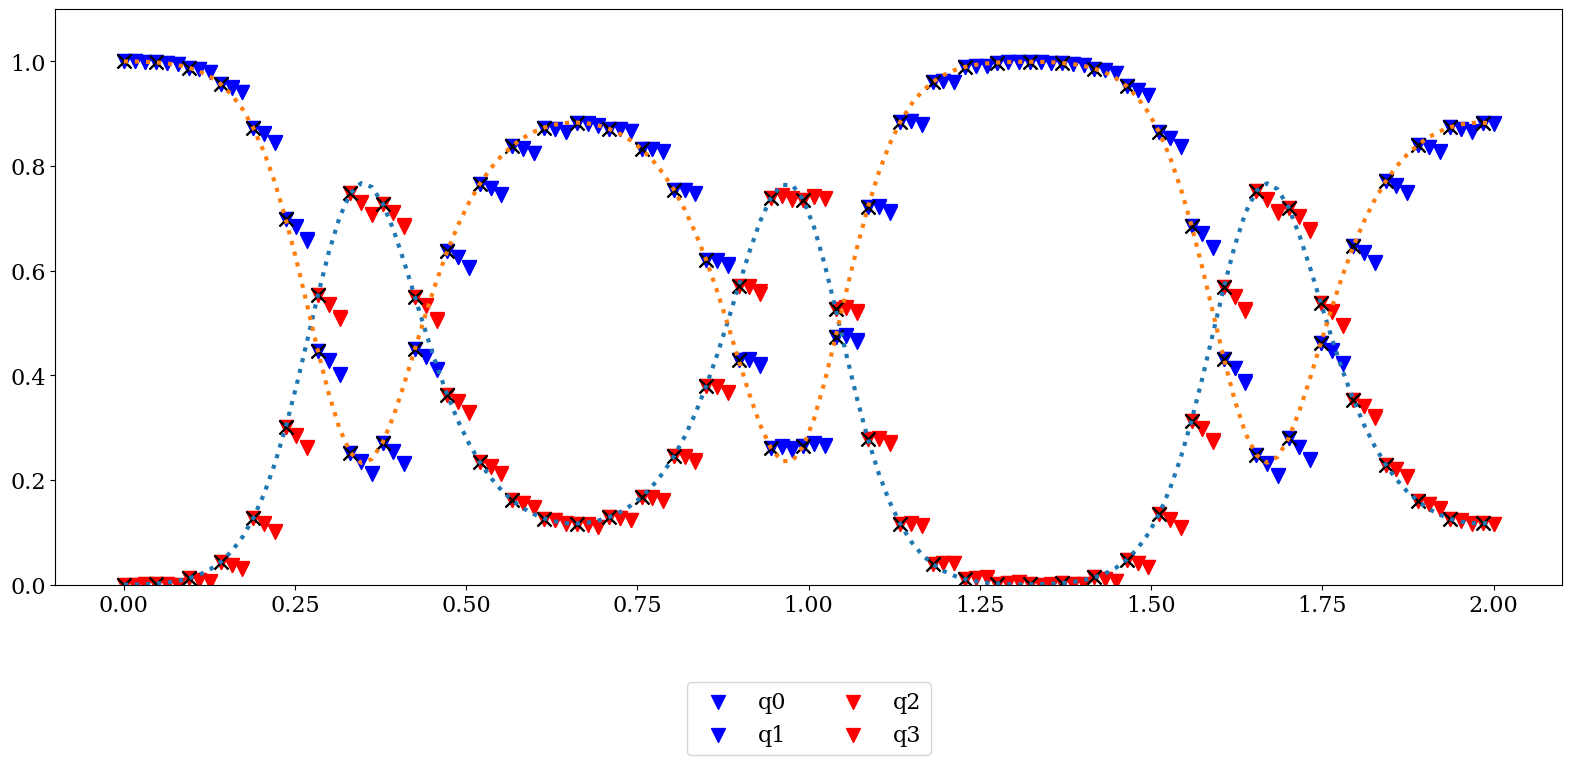

In [ ]:
L          = 2                          # baseline
t_steps    = 128                        # number of Trotter steps
theta      = 10 * np.pi/180.            # vacuum mixing angle
dmsq       = 1.0                        # mass squared difference
Delta      = dmsq / (2*0.1) * np.array([1.,1.,-1.,-1.])       # oscillation frequency; note the minus sign for the kinetic terms for antineutrinos
b          = np.array([np.sin(2*theta), 0, -np.cos(2*theta)]) # the structure of the vacuum Hamiltonian in the Pauli basis
J          = 5 * np.ones((4, 4))        # self-interaction strength
nu_mask    = [True,True,False,False]    # which qubits describe neutrinos?
nubar_mask = [False,False,True,True]    # which qubits describe antineutrinos?
J[nubar_mask,:] *= -1   # minus sign for mixed neutrino--antineutrino terms
J[:,nubar_mask] *= -1

INJECTION_INTERVAL = 3 # inject mean field solution every INJECTION_INTERVAL Trotter steps

# compute mean-field solution
L_table = np.linspace(0, L, t_steps)
sol     = P_osc_RS(L_table, theta, np.array([Delta[0], -Delta[0]]), 0., 2*J[::2,::2]) # factor 2 because we compare to a system with 2 nu + 2 nubar
P_table = np.reshape(sol.y, (2,3,len(L_table)))

# as neutrinos don't interact with themselves in the quantum algorithm,
# their same-sign partner is given double weight. This way, each particle
# should see the same effective number of neutrinos and antineutrinos.
J[np.ix_(nu_mask,nu_mask)]       *= 2
J[np.ix_(nubar_mask,nubar_mask)] *= 2


# corresponding change to coupling between neutrinos and antineutrinos
J[np.ix_(nu_mask,nubar_mask)] *= 1
J[np.ix_(nubar_mask,nu_mask)] *= 1
print(J)

# determine step size based on derivative of classical solution so that shorter Trotter steps are
# used in regions of rapid oscillation
# L_table_quant  = np.concatenate(([0], np.cumsum(1/np.abs(np.diff(P_table[0,2])))))
# L_table_quant *= L_table[-1]/L_table_quant[-1]
# L_table_quant = L_table # FIXME FIXME

L_table_quant = np.linspace(0, L, t_steps)  # FIXME FIXME

# loop over time steps
n_qubits = 4
dt_table = np.diff(L_table_quant)
qc = qk.QuantumCircuit(n_qubits)
for i in tqdm(range(len(dt_table))):
    dt = dt_table[i]

    # artificially remove entanglement between qubits (but not the superposition that each
    # qubit is in) by resetting each qubit to a non-entangled state
    qc_no_save = qc.remove_final_measurements(inplace=False)
    qc_no_save.data = [inst for inst in qc.data if inst.operation.name != 'save_density_matrix']
    sv = qk.quantum_info.Statevector(qc_no_save)
    rho = [ np.array(qk.quantum_info.partial_trace(sv, [j for j in range(n_qubits) if j != k])) for k in range(n_qubits) ]
    p   = [ np.real(np.array([ np.trace(sigma_1@rho[k]), np.trace(sigma_2@rho[k]), np.trace(sigma_3@rho[k]) ])) for k in range(n_qubits) ]

    """
    Reset results to theh mean field theory result
    """

    if i % INJECTION_INTERVAL == 0:

        p[2] = np.array([-P_table[1,0,i], -P_table[1,1,i], -P_table[1,2,i]])
        p[1] = p[0]
        p[3] = p[2]

        p[0] = np.array([P_table[0,0,i], P_table[0,1,i], P_table[0,2,i]])
        p[1] = p[0]
        p[3] = p[2]
    
    qc.reset(range(n_qubits))
    for j in range(n_qubits):
        qc.ry(np.arccos(p[j][2]), j)
        qc.rz(np.arctan2(p[j][1], p[j][0]), j)

    # save density matrix after each Trotter step for the final plot    
    qc.save_density_matrix(label=str(i+1))

    # carry out Trotter step (2nd-order Trotterization)
    for j in range(4):
        for k in range(j+1,4):
            qc.rx(dt*Delta[j]*b[0]/3, j)  # vacuum # FIXME sign???
            qc.rz(dt*Delta[j]*b[2]/3, j)
            qc.rx(dt*Delta[k]*b[0]/3, k)
            qc.rz(dt*Delta[k]*b[2]/3, k)
            qc.rxx(-dt*J[j,k], j, k)      # self-interaction
            qc.ryy(-dt*J[j,k], j, k)
            qc.rzz(-dt*J[j,k], j, k)
# end for (time steps)

# save final state
qc.save_density_matrix(label=str(i+2))

# run simulation    
sim = aer.AerSimulator(method="statevector", precision="double", zero_threshold=1e-14, validation_threshold=1e-12)
result = sim.run(qc).result()

# extract and plot results
n_qubits = qc.num_qubits
rho_reduced = [ { k : np.array(qk.quantum_info.partial_trace(result.data()[k], [q for q in range(n_qubits) if q != j])) for k in result.data().keys() } for j in range(n_qubits) ]
pp = np.array([ [[float(k), rho_reduced[j][k][0,0]] for k in rho_reduced[j].keys() ] for j in range(n_qubits) ])
pp = np.abs(np.take_along_axis(pp, pp[:,:,0].argsort(axis=1)[:,:,None], axis=1))
for j in range(n_qubits):
    plt.scatter(L_table_quant, pp[j, :, 1] if nu_mask[j] else 1 - pp[j, :, 1], label=f'q{j}', marker='v', s=100, color='blue' if nu_mask[j] else 'red')
for j in range(n_qubits):
    plt.scatter(L_table_quant[::INJECTION_INTERVAL], pp[j, ::INJECTION_INTERVAL, 1] if nu_mask[j] else 1 - pp[j, ::INJECTION_INTERVAL, 1], s=100, marker='x', color='black')
for k in range(len(P_table)):
    plt.plot(L_table, 0.5 * (1 - P_table[k, 2, :]), ls=':', lw=3)

plt.ylim(0, 1.1)

# Place legend centered below the x‐axis:
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),  # (0.5, -0.15) means “centered, 15% of height below the axes”
    ncol=2                       # adjust ncol to fit all labels on one line if desired
)

plt.tight_layout()
plt.show()